In [12]:

import glob
import os
import ozy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict


157


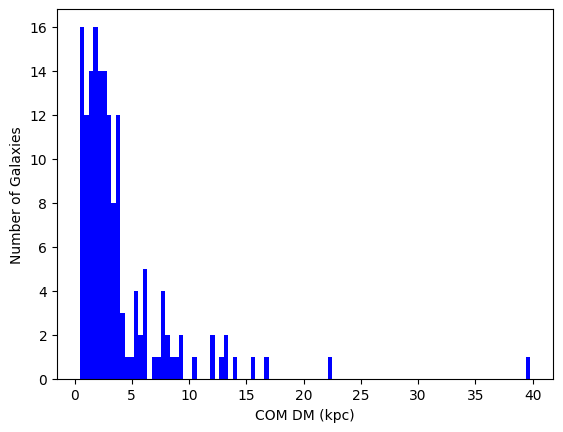

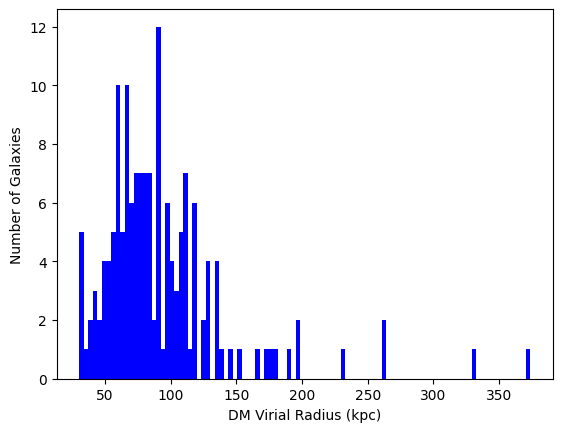

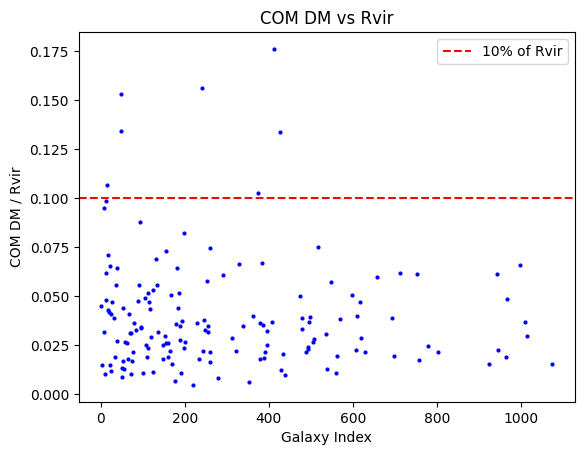

Number of verified galaxies: 150
Number of non verified galaxies: 7
[375, 427, 241, 413, 47, 49, 14]


In [15]:
df = pd.read_csv('COM_dm_gals.csv')

gals = df[df.columns[0]]

COM_dm = df[df.columns[1]]

dm_r_vir = df[df.columns[2]]

gals = np.array(gals)
COM_dm = np.array(COM_dm)
dm_r_vir = np.array(dm_r_vir)

print(len(gals))

mask = gals != 185

gals = gals[mask]
COM_dm = COM_dm[mask]
dm_r_vir = dm_r_vir[mask]


plt.hist(COM_dm, bins=100, label='COM DM', color='blue')
plt.xlabel('COM DM (kpc)')
plt.ylabel('Number of Galaxies')
plt.show()

plt.hist(dm_r_vir, bins=100, label='DM Virial Radius', color='blue')
plt.xlabel('DM Virial Radius (kpc)')
plt.ylabel('Number of Galaxies')
plt.show()

plt.plot(gals, COM_dm/dm_r_vir, 'o', markersize=2, color='blue')
plt.axhline(0.1, color='red', linestyle='--', label='10% of Rvir')

plt.ylabel('COM DM / Rvir')
plt.xlabel('Galaxy Index')
plt.title('COM DM vs Rvir')
plt.legend()
plt.show()

verified_gals = []
non_verified_gals = []

for i in range(len(gals)):
    if (COM_dm[i] / dm_r_vir[i]) <= 0.1:
        verified_gals.append(gals[i])
    else:
        non_verified_gals.append(int(gals[i]))

print(f'Number of verified galaxies: {len(verified_gals)}')
print('Number of non verified galaxies:', len(gals) - len(verified_gals))
        
print(non_verified_gals)